In [1]:
!pip install rioxarray geopandas cartopy pymannkendall

In [3]:
import xarray as xr
import geopandas as gpd
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pymannkendall as mk
import numpy as np
from scipy.stats import linregress

Resolution Check

In [11]:
#Resolution Check
et_raw = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Evapotranspiration/GLEAM_Evapotranspiration(merged)_2000_2024.nc")
print(et_raw)

lat = et_raw["lat"].values
lon = et_raw["lon"].values

lat_res = abs(lat[1] - lat[0])
lon_res = abs(lon[1] - lon[0])

print("Lat resolution ~", lat_res, "degrees")
print("Lon resolution ~", lon_res, "degrees at equator")

<xarray.Dataset> Size: 8GB
Dimensions:  (time: 300, lat: 1800, lon: 3600)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-01-31 2000-02-29 ... 2024-12-31
  * lat      (lat) float64 14kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
Data variables:
    ET       (time, lat, lon) float32 8GB ...
Lat resolution ~ 0.09999999999999432 degrees
Lon resolution ~ 0.09999999999999432 degrees at equator


Nearest Neighbor Interpolation to 0.25 degree cell

In [ ]:
et_raw = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Evapotranspiration/GLEAM_Evapotranspiration(merged)_2000_2024.nc")

new_lat = np.arange(et_raw.lat.min(), et_raw.lat.max(), 0.25)
new_lon = np.arange(et_raw.lon.min(), et_raw.lon.max(), 0.25)

et_025 = et_raw.interp(lat=new_lat, lon=new_lon, method="nearest")

#et_025.to_netcdf(r"D:\Projects\GNR644 - Water Balance\Evapotranspiration\GLEAM_Evapotranspiration_resampled_NN.nc")

Monthly Mean Analysis

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


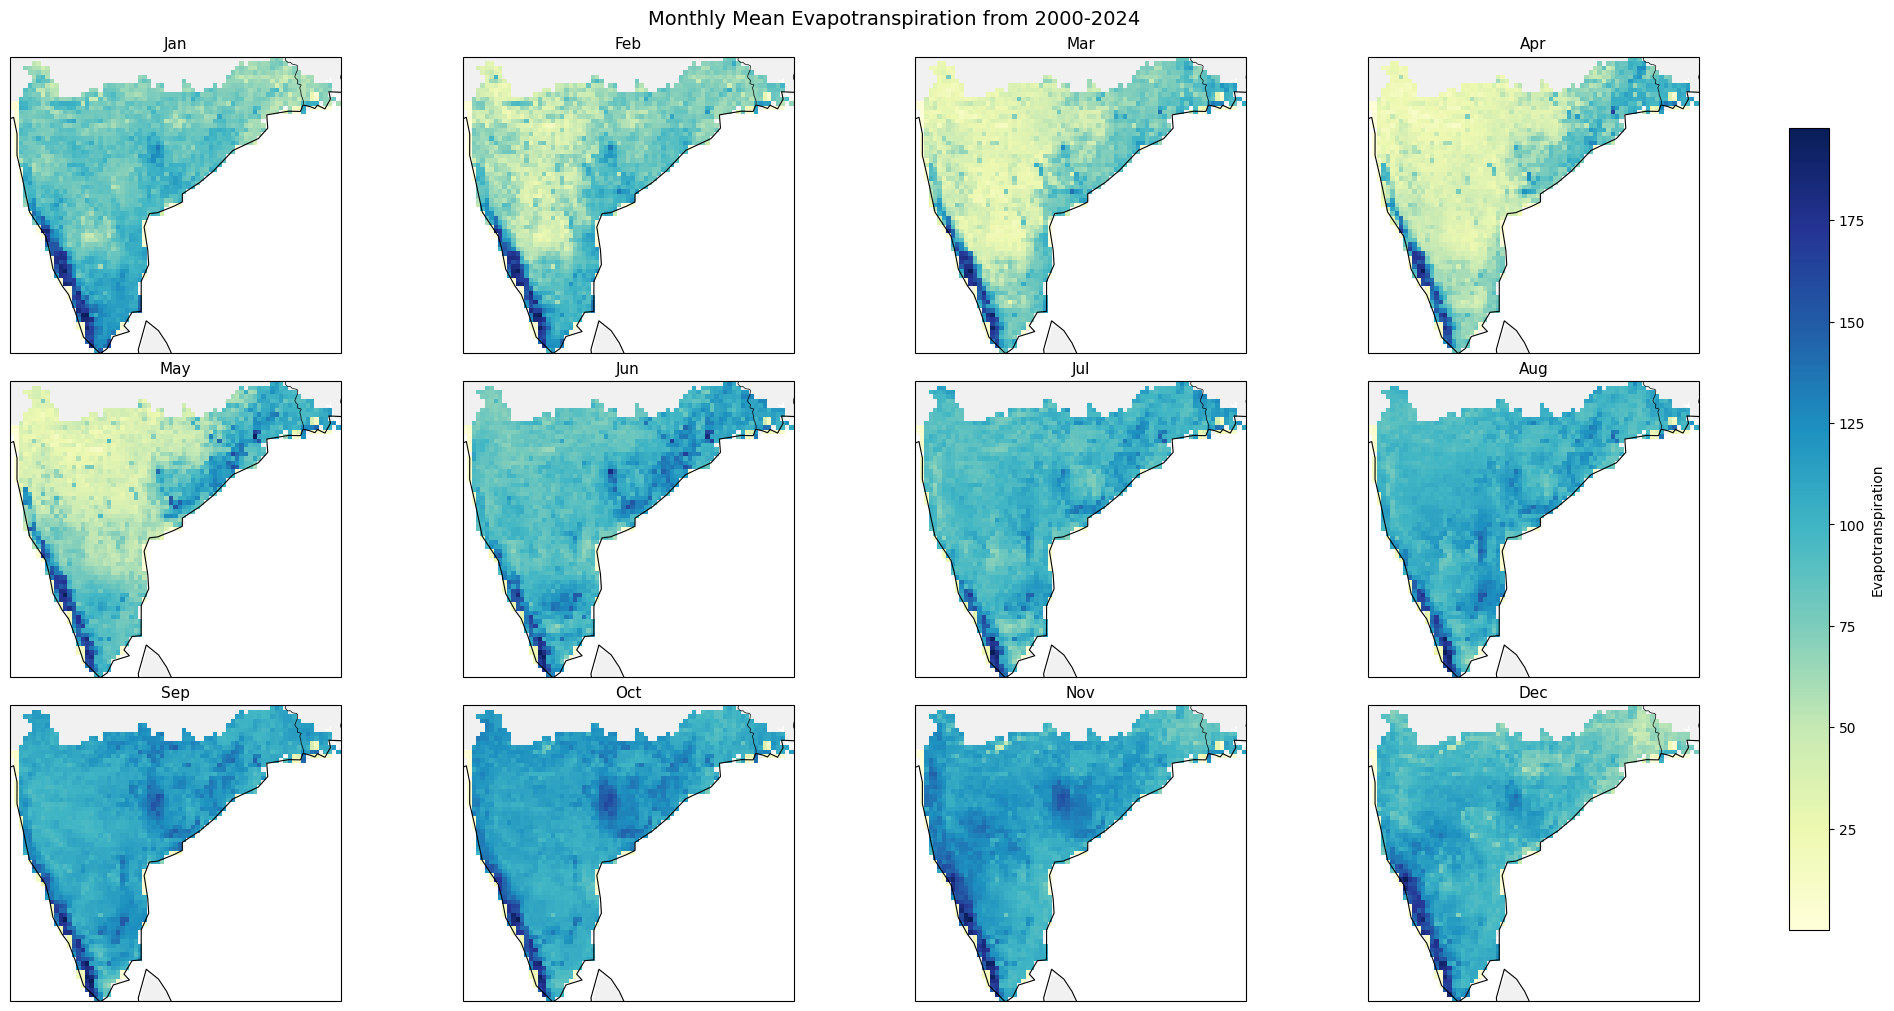

In [4]:
et_025 = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Evapotranspiration/GLEAM_Evapotranspiration_resampled_NN.nc")
et = et_025["ET"]   # change variable name if needed


# Monthly climatology

monthly_mean = et.groupby("time.month").mean(dim="time")

# Plot settings
projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="YlGnBu",
        add_colorbar=False
    )

    # Base map features
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    ax.set_title(months[i], fontsize=11)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Evapotranspiration")

plt.suptitle(
    "Monthly Mean Evapotranspiration from 2000-2024",
    fontsize=14
)

plt.show()


Monthly Mann Kendall Trend Analysis

In [5]:
# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:   # safety check
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
results = {}

for month in range(1, 13):

    et_m = et.sel(time=et["time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        et_m,
        input_core_dims=[["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })

# -------------------------------
# Example: January trend map
# -------------------------------
results[1]

<xarray.Dataset> Size: 162kB
Dimensions:     (lat: 67, lon: 75)
Coordinates:
  * lat         (lat) float64 536B 8.15 8.4 8.65 8.9 ... 23.9 24.15 24.4 24.65
  * lon         (lon) float64 600B 72.55 72.8 73.05 73.3 ... 90.55 90.8 91.05
Data variables:
    trend       (lat, lon) object 40kB nan nan nan nan nan ... nan nan nan nan
    z_value     (lat, lon) float64 40kB nan nan nan nan nan ... nan nan nan nan
    p_value     (lat, lon) float64 40kB nan nan nan nan nan ... nan nan nan nan
    sens_slope  (lat, lon) float64 40kB nan nan nan nan nan ... nan nan nan nan

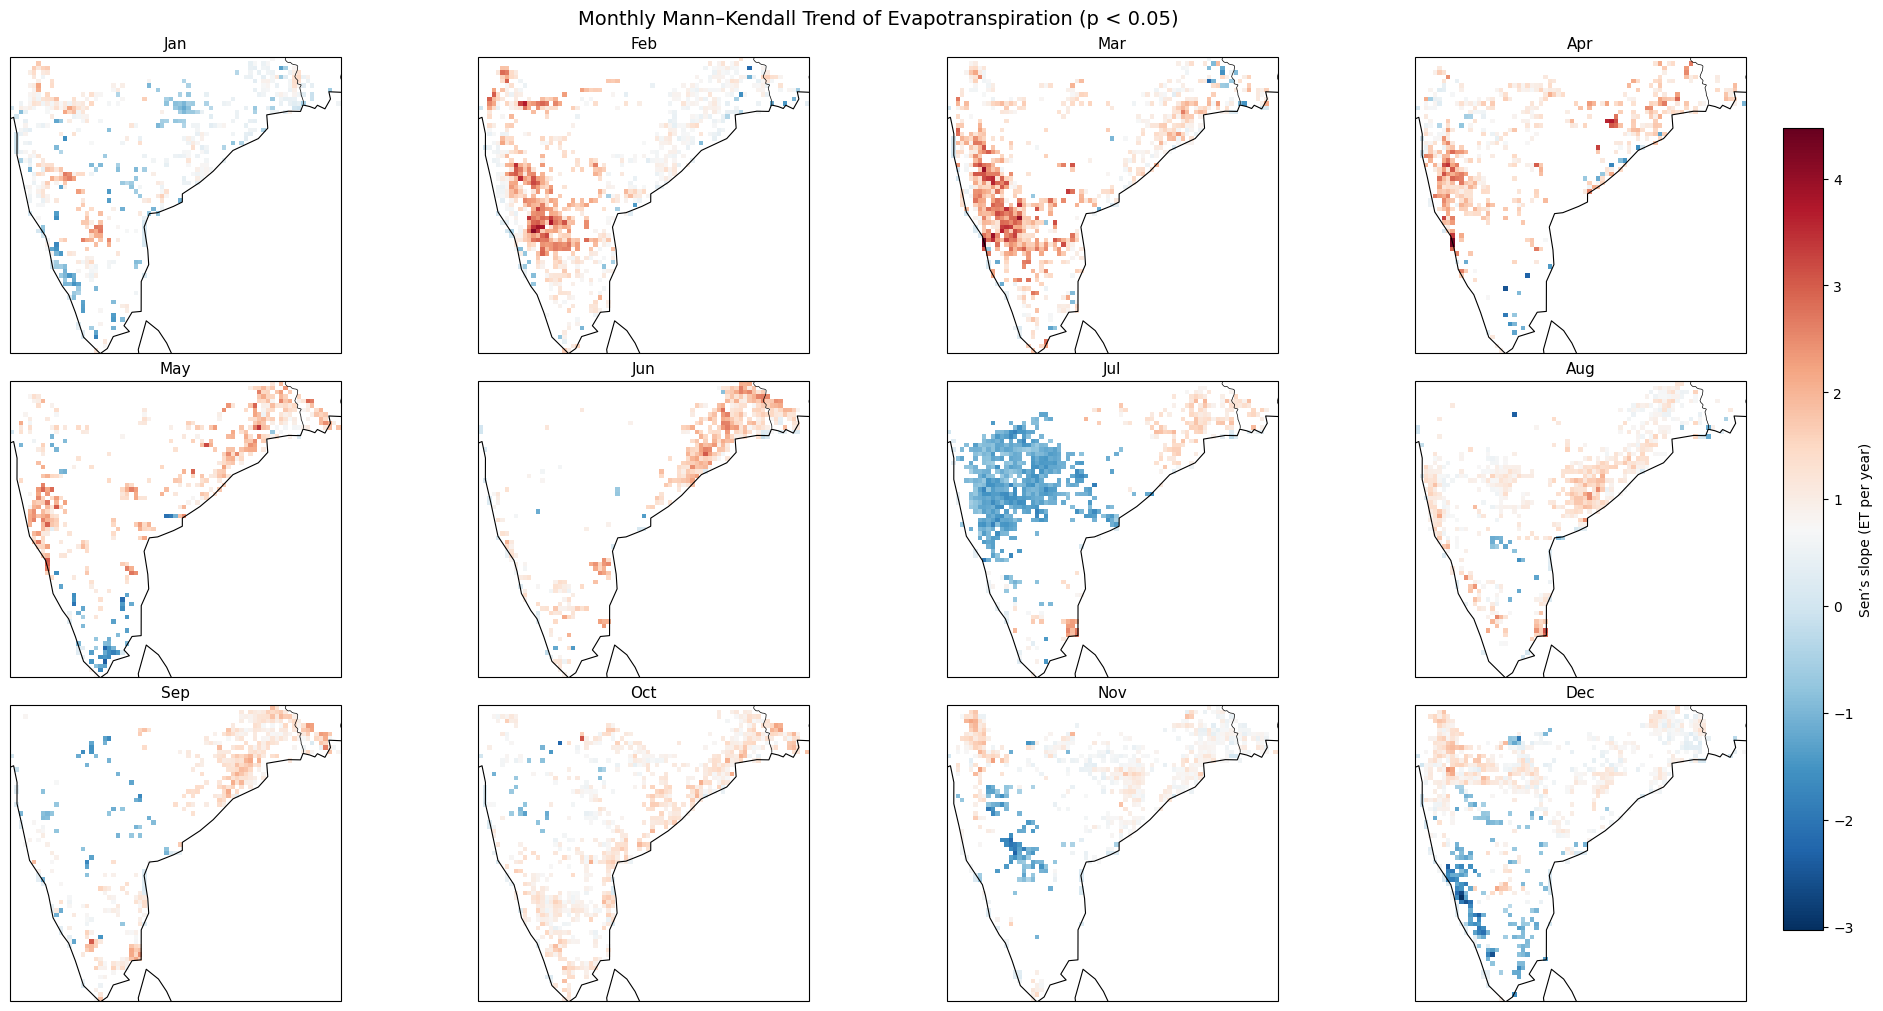

In [6]:
# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (important)
# ---------------------------------
all_slopes = []

for m in range(1, 13):
    slope = results[m]["sens_slope"]
    sig = slope.where(results[m]["p_value"] < 0.05)
    all_slopes.append(sig)

vmin = np.nanmin([s.min().values for s in all_slopes])
vmax = np.nanmax([s.max().values for s in all_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1

    ds_mk = results[month]

    sig_slope = ds_mk["sens_slope"].where(
        ds_mk["p_value"] < 0.05
    )

    im = sig_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # Basemap
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional: restrict extent (example: India)
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)
cbar.set_label("Sen’s slope (ET per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Evapotranspiration (p < 0.05)",
    fontsize=14
)

plt.show()


Time Series Graph of Mean

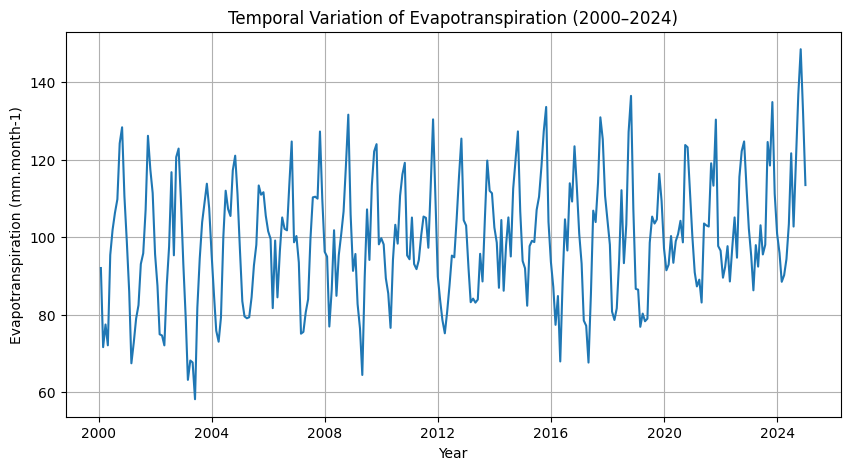

In [ ]:
et_ts = et.mean(dim=['lat','lon'])
plt.figure(figsize=(10,5))

et_ts.plot(label='Evapotranspiration')

plt.title("Temporal Variation of Evapotranspiration (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Evapotranspiration (mm.month-1)")
plt.grid(True)

plt.show()

Grouping of Mean by month

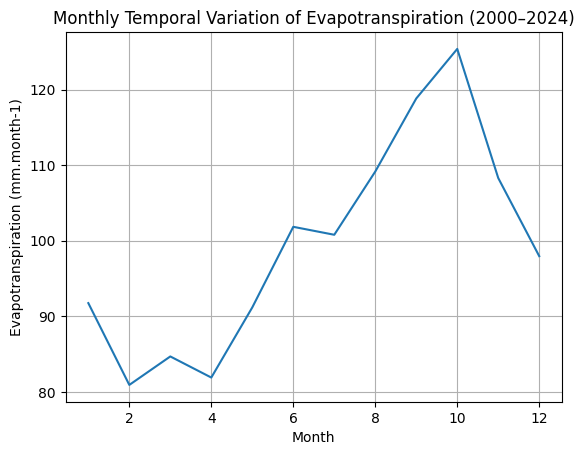

In [ ]:
et_season = et_ts.groupby('time.month').mean()
et_season.plot(label='ET')
plt.title("Monthly Temporal Variation of Evapotranspiration (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Evapotranspiration (mm.month-1)")
plt.grid(True)

Trend Analysis

In [ ]:
time_et = np.arange(len(et_ts))

slope, intercept, r, p, std = linregress(time_et, et_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 0.039188542516127245
p-value: 0.0001663482685154375


Pixel wise Trend using MK Test (not like previous one where we perfrom MK Test month wise, here we perform MK Test Overall)

In [ ]:
def trend_calc(y):
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for Evapotranspiration from 2000 to 2024')

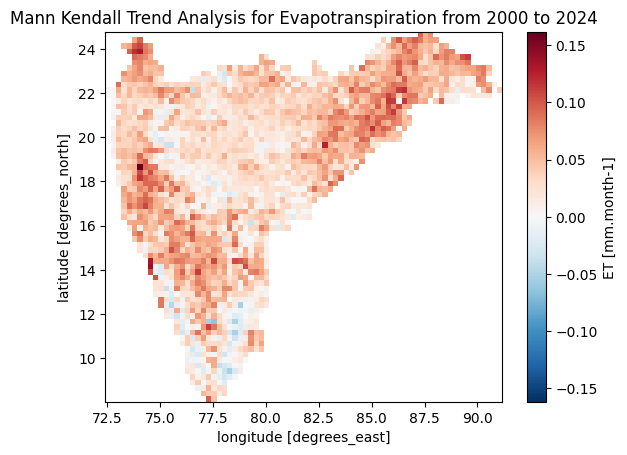

In [ ]:
et_trend = xr.apply_ufunc(
    trend_calc,
    et,
    input_core_dims=[['time']],
    vectorize=True
)

et_trend.plot()
plt.title("Mann Kendall Trend Analysis for Evapotranspiration from 2000 to 2024")

Anomaly to find Drought years

Text(0.5, 1.0, 'Anomaly TSA Plot for Evapotranspiration')

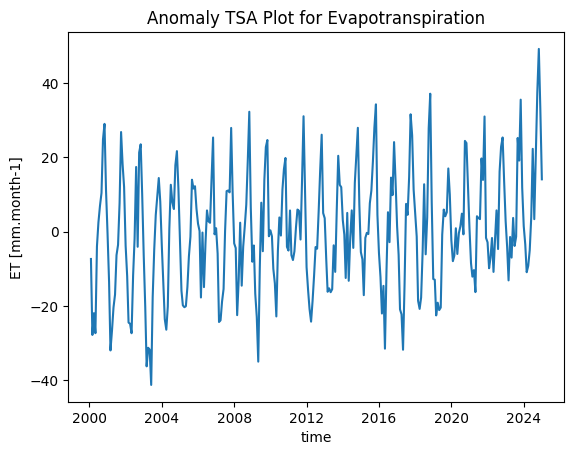

In [ ]:
et_mean = et_ts.mean()
et_anomaly = et_ts - et_mean

et_anomaly.plot()
plt.title("Anomaly TSA Plot for Evapotranspiration")